(5, 1)
z1 [[0.35281047 0.08003144 0.1957476  0.44817864 0.3735116 ]
 [0.70562094 0.16006288 0.39149519 0.89635728 0.7470232 ]
 [1.05843141 0.24009433 0.58724279 1.34453592 1.12053479]
 [1.41124188 0.32012577 0.78299039 1.79271456 1.49404639]
 [1.76405235 0.40015721 0.97873798 2.2408932  1.86755799]]
z1 [[0.35281047 0.08003144 0.1957476  0.44817864 0.3735116 ]
 [0.70562094 0.16006288 0.39149519 0.89635728 0.7470232 ]
 [1.05843141 0.24009433 0.58724279 1.34453592 1.12053479]
 [1.41124188 0.32012577 0.78299039 1.79271456 1.49404639]
 [1.76405235 0.40015721 0.97873798 2.2408932  1.86755799]]
epoch 0, loss 1.6072
z1 [[0.21978245 0.20935841 0.17514471 0.43412839 0.42940267]
 [0.5562368  0.30529091 0.36835913 0.88057952 0.80978621]
 [0.89269115 0.40122342 0.56157355 1.32703064 1.19016975]
 [1.2291455  0.49715592 0.75478797 1.77348177 1.57055329]
 [1.56559985 0.59308843 0.94800239 2.2199329  1.95093683]]
z1 [[0.21978245 0.20935841 0.17514471 0.43412839 0.42940267]
 [0.5562368  0.30529091 0.368

c:\Users\tom\anaconda3\envs\env_llm\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\tom\anaconda3\envs\env_llm\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


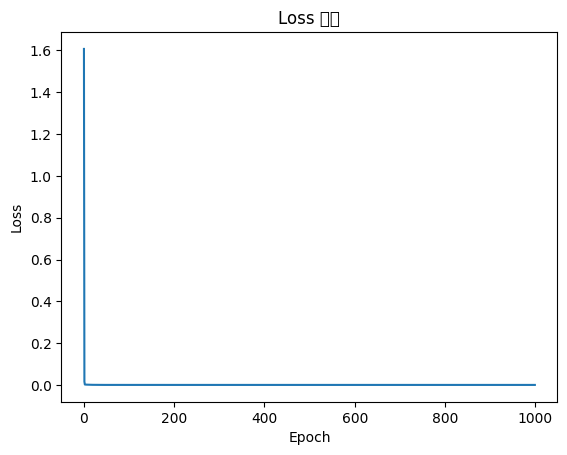

c:\Users\tom\anaconda3\envs\env_llm\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\tom\anaconda3\envs\env_llm\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\tom\anaconda3\envs\env_llm\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\tom\anaconda3\envs\env_llm\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\tom\anaconda3\envs\env_llm\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing fro

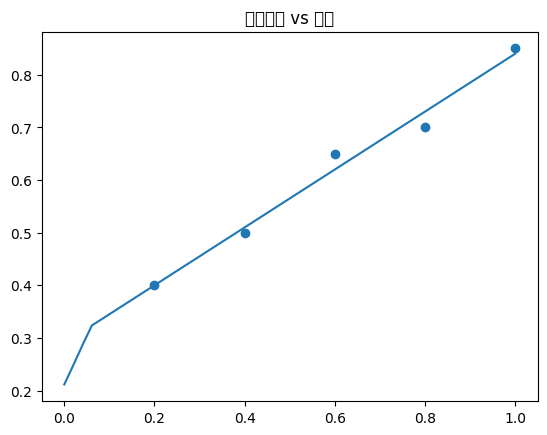

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. 데이터 (공부시간 → 점수)
# -------------------------
x = np.array([[1], [2], [3], [4], [5]], dtype=float)
print(x.shape)
y = np.array([[40], [50], [65], [70], [85]], dtype=float)

# 정규화 (중요🔥)
x = x / 5.0
y = y / 100.0

# -------------------------
# 2. 가중치 초기화
# -------------------------
np.random.seed(0)
W1 = np.random.randn(1, 5)
b1 = np.zeros((1, 5))

W2 = np.random.randn(5, 1)
b2 = np.zeros((1, 1))

# -------------------------
# 3. 활성화 함수
# -------------------------
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# -------------------------
# 4. 학습
# -------------------------
lr = 0.05
losses = []

for epoch in range(1000):

    # forward
    z1 = x @ W1 + b1
    print("z1",z1)
    a1 = relu(z1)
    print("z1",a1)

    z2 = a1 @ W2 + b2
    y_pred = z2

    # loss
    loss = np.mean((y - y_pred) ** 2)
    losses.append(loss)

    # backward
    d_loss = 2 * (y_pred - y) / y.shape[0]

    dW2 = a1.T @ d_loss
    db2 = np.sum(d_loss, axis=0, keepdims=True)

    da1 = d_loss @ W2.T
    dz1 = da1 * relu_derivative(z1)

    dW1 = x.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # update
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    if epoch % 100 == 0:
        print(f"epoch {epoch}, loss {loss:.4f}")

# -------------------------
# 5. 결과 확인
# -------------------------
print("\n예측 결과 (정규화된 값):")
print(y_pred)

# 실제 값으로 복원
print("\n실제 점수 예측:")
print(y_pred * 100)

# -------------------------
# 6. 그래프
# -------------------------
plt.plot(losses)
plt.title("Loss 감소")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 예측 곡선
x_test = np.linspace(0, 1, 50).reshape(-1,1)
z1 = x_test @ W1 + b1
a1 = relu(z1)
y_test = a1 @ W2 + b2

plt.scatter(x, y)
plt.plot(x_test, y_test)
plt.title("공부시간 vs 점수")
plt.show()


입력층              은닉층                     출력층
  x        →     (  ●       ●  )        →        y
               z1₁     z1₂                y_pred

# 최종그림
x
 ...
  → z1₁ = x·w11 + b1₁
  → z1₂ = x·w12 + b1₂
 ...
  → a1₁ = ReLU(z1₁)
  → a1₂ = ReLU(z1₂)
 ...
  → y = a1₁·w21 + a1₂·w22 + b2

# 최종한방 그림

        z1 = xW1 + b1
x ........................→ z1
  ...                      ...
   ... → a1 = ReLU(z1)     ...
    ...                    ...
     ... → y = a1W2 + b2  → y_pred
                              ↓
                              ↓
     ← ← ← ← ← ← ← ← ← ← ← ← ←
          Backprop (오차 전달)

![alt text](image.png)

![alt text](image-1.png)